In [1]:
import torch
import time
import matplotlib.pyplot as plt
import numpy as np
import random

In [2]:
class ScoreNet(torch.nn.Module):
    def __init__(self, dim, hidden_dim=128):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(dim, hidden_dim),
            torch.nn.SiLU(),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.SiLU(),
            torch.nn.Linear(hidden_dim, dim)
        )

    def forward(self, x):
        return self.net(x)




In [ ]:

def loss_classical(model, x):
    x.requires_grad_(True)
    s = model(x)
    trace = 0.0
    for i in range(x.shape[1]):
        grad_s_i = torch.autograd.grad(
            outputs=s[:, i].sum(), inputs=x, create_graph=True, retain_graph=True
        )[0]
        trace += grad_s_i[:, i]
    return (trace + 0.5 * (s ** 2).sum(dim=-1)).mean()

def loss_dsm(model, x, sigma=0.1):
    noise = torch.randn_like(x) * sigma
    x_tilde = x + noise
    s = model(x_tilde)
    target = -noise / (sigma ** 2)
    return (0.5 * torch.sum((s - target) ** 2, dim=-1)).mean()

def loss_ssm_vr(model, x):
    x.requires_grad_(True)
    v = torch.randint_like(x, 0, 2).float() * 2 - 1.0
    s = model(x)
    v_dot_s = torch.sum(v * s, dim=-1)
    grad_v_dot_s = torch.autograd.grad(
        outputs=v_dot_s.sum(), inputs=x, create_graph=True
    )[0]
    v_dot_grad_v = torch.sum(v * grad_v_dot_s, dim=-1)
    return (0.5 * torch.sum(s ** 2, dim=-1) + v_dot_grad_v).mean()

def loss_fdsm(model, x, epsilon=0.01):
    v = torch.randint_like(x, 0, 2).float() * 2 - 1.0  # Rademacher
    v_scaled = v * epsilon
    
    # parallelise 
    x_plus = x + v_scaled
    x_minus = x - v_scaled
    x_combined = torch.cat([x_plus, x_minus], dim=0)
    
    s_combined = model(x_combined)
    s_plus, s_minus = torch.chunk(s_combined, 2, dim=0)
    
    term1 = 0.125 * torch.sum((s_plus + s_minus) ** 2, dim=-1)
    
    v_dot_s_plus = torch.sum(v_scaled * s_plus, dim=-1)
    v_dot_s_minus = torch.sum(v_scaled * s_minus, dim=-1)
    term2 = (1.0 / (2 * epsilon ** 2)) * (v_dot_s_plus - v_dot_s_minus)
    
    loss = term1 + term2
    return loss.mean()


In [ ]:
def run_benchmark_and_plot():
    device = torch.device("cpu")
    print(f"Running on: {device}\n")
    
    batch_size = 64
    iterations = 1000
    
    # testing lots of dimensions
    dimensions = [10, 20, 30, 40, 50, 60, 70,80,90, 100]
    
    methods = {
        "Classical": loss_classical,
        "DSM": loss_dsm,
        "SSM-VR": loss_ssm_vr,
        "FDSM": loss_fdsm
    }
    results = {name: [] for name in methods.keys()}
    
    for d in dimensions:
        print(f"--- Dimension: {d} ---")
        model = ScoreNet(d).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        x = torch.randn(batch_size, d, device=device)
        
        for name, loss_fn in methods.items():
            # warmup
            for _ in range(20):
                optimizer.zero_grad()
                loss = loss_fn(model, x)
                loss.backward()
                optimizer.step()
                
            # timed run
            start_time = time.perf_counter()
            for _ in range(iterations):
                optimizer.zero_grad()
                loss = loss_fn(model, x)
                loss.backward()
                optimizer.step()
            end_time = time.perf_counter()
            
            avg_time_ms = ((end_time - start_time) / iterations) * 1000
            results[name].append(avg_time_ms)
            print(f"{name:>10}: {avg_time_ms:.2f} ms / step")
        print("")

    plt.figure(figsize=(10, 6))
    
    for name, times in results.items():
        marker = 'o' if name == 'Classical' else 's' if name == 'DSM' else '^' if name == 'SSM-VR' else 'D'
        plt.plot(dimensions, times, label=name, marker=marker, linewidth=2)
        
    plt.title('Computation Time vs Data Dimension', fontsize=16)
    plt.xlabel('Dimension (d)', fontsize=14)
    plt.ylabel('Average Time per Step (ms)', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    plt.tight_layout()
    
    plt.show()
    

In [4]:
def set_seed(seed=50):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

set_seed()

Running on: cpu

--- Dimension: 10 ---
 Classical: 6.31 ms / step
       DSM: 0.95 ms / step
    SSM-VR: 1.54 ms / step
      FDSM: 1.25 ms / step

--- Dimension: 20 ---
 Classical: 11.88 ms / step
       DSM: 1.00 ms / step
    SSM-VR: 1.58 ms / step
      FDSM: 1.27 ms / step

--- Dimension: 30 ---
 Classical: 17.70 ms / step
       DSM: 1.00 ms / step
    SSM-VR: 1.60 ms / step
      FDSM: 1.29 ms / step

--- Dimension: 40 ---
 Classical: 23.17 ms / step
       DSM: 1.06 ms / step
    SSM-VR: 1.62 ms / step
      FDSM: 1.32 ms / step

--- Dimension: 50 ---
 Classical: 30.24 ms / step
       DSM: 1.03 ms / step
    SSM-VR: 1.64 ms / step
      FDSM: 1.34 ms / step

--- Dimension: 60 ---
 Classical: 34.79 ms / step
       DSM: 1.12 ms / step
    SSM-VR: 1.74 ms / step
      FDSM: 1.38 ms / step

--- Dimension: 70 ---
 Classical: 40.98 ms / step
       DSM: 1.06 ms / step
    SSM-VR: 1.66 ms / step
      FDSM: 1.38 ms / step

--- Dimension: 80 ---
 Classical: 46.72 ms / step
       DSM

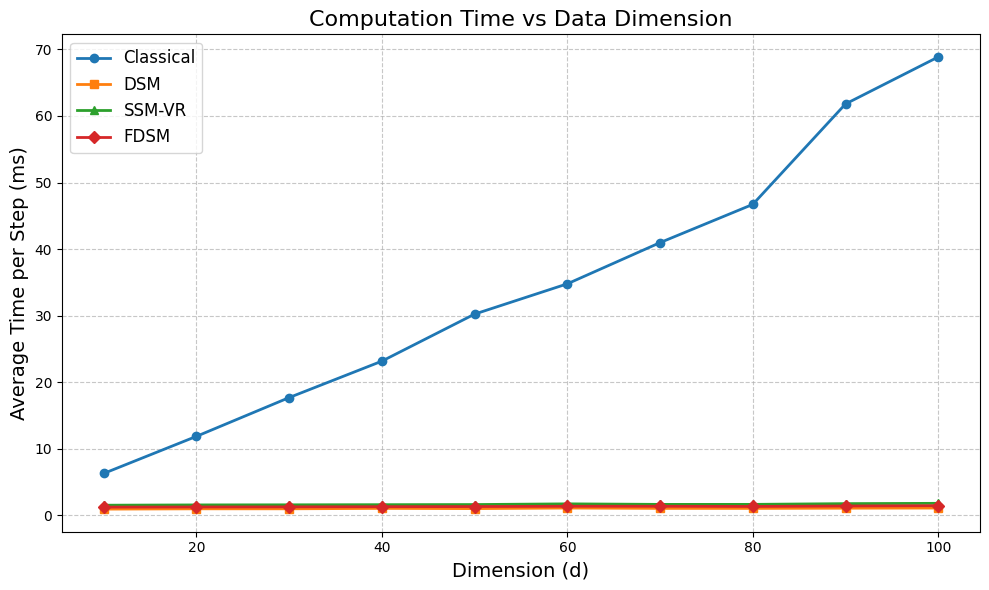

In [9]:
run_benchmark_and_plot()

In [13]:

def loss_dsm(model, x, sigma=0.1):
    noise = torch.randn_like(x) * sigma
    x_tilde = x + noise
    s = model(x_tilde)
    target = -noise / (sigma ** 2)
    return (0.5 * torch.sum((s - target) ** 2, dim=-1)).mean()

def loss_ssm_vr(model, x):
    x.requires_grad_(True)
    v = torch.randint_like(x, 0, 2).float() * 2 - 1.0
    s = model(x)
    v_dot_s = torch.sum(v * s, dim=-1)
    grad_v_dot_s = torch.autograd.grad(
        outputs=v_dot_s.sum(), inputs=x, create_graph=True
    )[0]
    v_dot_grad_v = torch.sum(v * grad_v_dot_s, dim=-1)
    return (0.5 * torch.sum(s ** 2, dim=-1) + v_dot_grad_v).mean()

def loss_fdsm(model, x, epsilon=0.01):
    
    v = torch.randint_like(x, 0, 2).float() * 2 - 1.0  # Rademacher
    v_scaled = v * epsilon
    
    x_plus = x + v_scaled
    x_minus = x - v_scaled
    x_combined = torch.cat([x_plus, x_minus], dim=0)
    
    s_combined = model(x_combined)
    s_plus, s_minus = torch.chunk(s_combined, 2, dim=0)
    
    term1 = 0.125 * torch.sum((s_plus + s_minus) ** 2, dim=-1)
    
    v_dot_s_plus = torch.sum(v_scaled * s_plus, dim=-1)
    v_dot_s_minus = torch.sum(v_scaled * s_minus, dim=-1)
    term2 = (1.0 / (2 * epsilon ** 2)) * (v_dot_s_plus - v_dot_s_minus)
    
    loss = term1 + term2
    return loss.mean()

def loss_fdsm_sequential(model, x, epsilon=0.01):
    v = torch.randint_like(x, 0, 2).float() * 2 - 1.0
    v_scaled = v * epsilon
    
    s_plus = model(x + v_scaled)
    s_minus = model(x - v_scaled)
    
    term1 = 0.125 * torch.sum((s_plus + s_minus) ** 2, dim=-1)
    
    v_dot_s_plus = torch.sum(v_scaled * s_plus, dim=-1)
    v_dot_s_minus = torch.sum(v_scaled * s_minus, dim=-1)
    term2 = (1.0 / (2 * epsilon ** 2)) * (v_dot_s_plus - v_dot_s_minus)
    
    loss = (term1 + term2).mean()
    return loss


def run_benchmark_and_plot():
    device = torch.device("cpu")
    torch.set_num_threads(2)
    print(f"Running on: {device}\n")
    
    batch_size = 64
    iterations = 1100
    
    dimensions = [10,30,60,100,180,320,500]
    
    methods = {
        "DSM": loss_dsm,
        "SSM-VR": loss_ssm_vr,
        "FDSM-VR": loss_fdsm,
        "FDSM-VR (Non-Parallel)": loss_fdsm_sequential
    }
    
    results = {name: [] for name in methods.keys()}
    
    for d in dimensions:
        print(f"--- Dimension: {d} ---")
        model = ScoreNet(d).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        x = torch.randn(batch_size, d, device=device)
        
        for name, loss_fn in methods.items():
            # warmup
            for _ in range(20):
                optimizer.zero_grad()
                loss = loss_fn(model, x)
                loss.backward()
                optimizer.step()
                
            # timed run
            start_time = time.perf_counter()
            for _ in range(iterations):
                optimizer.zero_grad()
                loss = loss_fn(model, x)
                loss.backward()
                optimizer.step()
            end_time = time.perf_counter()
            
            avg_time_ms = ((end_time - start_time) / iterations) * 1000
            results[name].append(avg_time_ms)
            print(f"{name:>10}: {avg_time_ms:.2f} ms / step")
        print("")

    plt.figure(figsize=(10, 6))

    line_colours = {
        "DSM": "orange",
        "SSM-VR": "green",
        "FDSM-VR": "red",
        "FDSM-VR (Non-Parallel)": "purple"
    }
    
    for name, times in results.items():
        marker = 's' if name == 'DSM' else '^' if name == 'SSM-VR' else 'D'
        plt.plot(dimensions, times, label=name, marker=marker, linewidth=2, color=line_colours[name])
        
    plt.title('Computation Time vs Data Dimension', fontsize=16)
    plt.xlabel('Dimension (d)', fontsize=14)
    plt.ylabel('Average Time per Step (ms)', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    plt.tight_layout()
    

    plt.show()



Running on: cpu

--- Dimension: 10 ---
       DSM: 0.67 ms / step
    SSM-VR: 1.18 ms / step
   FDSM-VR: 0.89 ms / step
FDSM-VR (Non-Parallel): 1.04 ms / step

--- Dimension: 30 ---
       DSM: 0.72 ms / step
    SSM-VR: 1.14 ms / step
   FDSM-VR: 0.91 ms / step
FDSM-VR (Non-Parallel): 1.01 ms / step

--- Dimension: 60 ---
       DSM: 0.72 ms / step
    SSM-VR: 1.19 ms / step
   FDSM-VR: 1.07 ms / step
FDSM-VR (Non-Parallel): 1.07 ms / step

--- Dimension: 100 ---
       DSM: 0.77 ms / step
    SSM-VR: 1.29 ms / step
   FDSM-VR: 1.07 ms / step
FDSM-VR (Non-Parallel): 1.18 ms / step

--- Dimension: 180 ---
       DSM: 0.90 ms / step
    SSM-VR: 1.48 ms / step
   FDSM-VR: 1.26 ms / step
FDSM-VR (Non-Parallel): 1.47 ms / step

--- Dimension: 320 ---
       DSM: 1.22 ms / step
    SSM-VR: 1.63 ms / step
   FDSM-VR: 1.48 ms / step
FDSM-VR (Non-Parallel): 1.61 ms / step

--- Dimension: 500 ---
       DSM: 1.26 ms / step
    SSM-VR: 2.06 ms / step
   FDSM-VR: 1.78 ms / step
FDSM-VR (Non-Paral

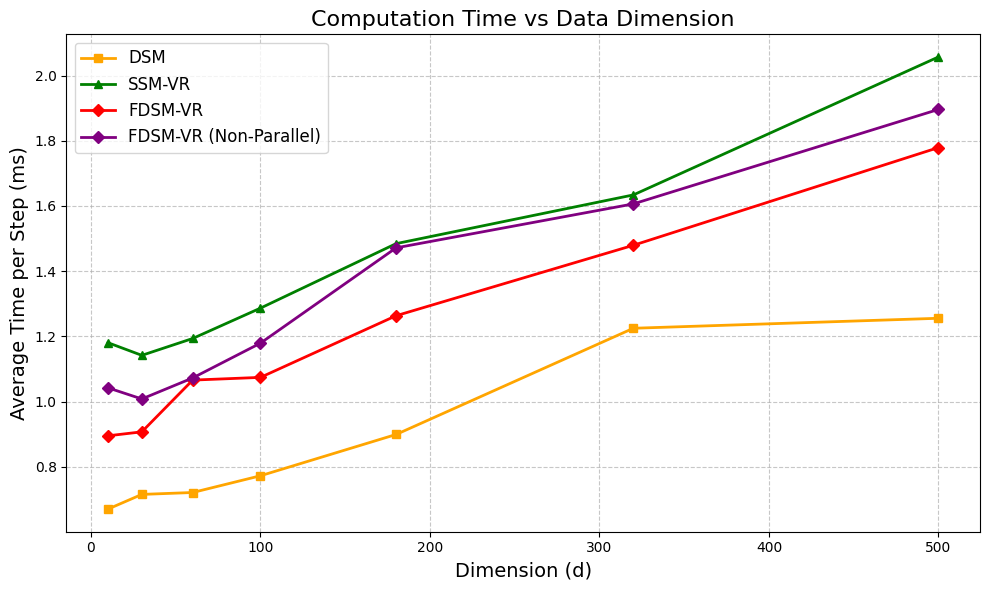

In [14]:
run_benchmark_and_plot()